<a href="https://colab.research.google.com/github/valenacu18/mi-primer-repo/blob/main/primer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets evaluate
from transformers import pipeline

# Cargar un pipeline de clasificación de texto
classifier = pipeline("sentiment-analysis")

# Probar con un texto
resultado = classifier("Aprender a programar inteligencia artificial en Google Colab es genial")
print(resultado)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.9970218539237976}]


In [ ]:
import pandas as pd

# Cargar un dataset público desde una URL directamente con Pandas
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Mostrar las primeras 5 filas de la tabla
print("--- PRIMERAS 5 FILAS DEL DATASET ---")
df.head()

--- PRIMERAS 5 FILAS DEL DATASET ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Entradas (X): Todas las columnas excepto 'species'
X = df.drop(columns=['species'])

# Respuestas (y): Solo la columna 'species'
y = df['species']

print(f"Total de muestras en el dataset: {len(df)}")


Total de muestras en el dataset: 150


In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el dataset: 80% para entrenar y 20% para probar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Mostrar los tamaños de cada conjunto
print(f"Muestras para Entrenar (Train): {len(X_train)} (80%)")
print(f"Muestras para Probar (Test): {len(X_test)} (20%)")

Muestras para Entrenar (Train): 120 (80%)
Muestras para Probar (Test): 30 (20%)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Crear el modelo de IA (el "cerebro" en blanco)
modelo = DecisionTreeClassifier(random_state=42)

# 2. Entrenar el modelo con los datos de ENTRENAMIENTO
# Aquí la IA analiza X_train e y_train para aprender los patrones
modelo.fit(X_train, y_train)
print("¡El modelo se ha entrenado correctamente!\n")

# 3. Probar el modelo con los datos de PRUEBA (X_test)
# Le mostramos solo las medidas de las flores que NUNCA ha visto antes
predicciones = modelo.predict(X_test)

# 4. Evaluar qué tan preciso es el modelo
# Comparamos las respuestas reales (y_test) con las que predijo la IA
exactitud = accuracy_score(y_test, predicciones)

print(f"--- RESULTADOS DE LA EVALUACIÓN ---")
print(f"Precisión general (Accuracy): {exactitud * 100:.2f}%\n")

# Mostrar un informe más detallado por cada especie de flor
print("Informe detallado por especie:")
print(classification_report(y_test, predicciones))

¡El modelo se ha entrenado correctamente!

--- RESULTADOS DE LA EVALUACIÓN ---
Precisión general (Accuracy): 100.00%

Informe detallado por especie:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Definimos las medidas de una nueva flor:
# [sepal_length, sepal_width, petal_length, petal_width]
nueva_flor = [[5.1, 3.5, 1.4, 0.2]]

# Le pedimos al modelo que adivine la especie
especie_predicha = modelo.predict(nueva_flor)
print(f"La especie predicha para la nueva flor es: {especie_predicha[0]}")

La especie predicha para la nueva flor es: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Crear el dataset simulado con datos de videojuegos
datos = {
    'Nombre_Juego': [
        'CyberQuest', 'PixelKnight', 'GalaxyWars', 'FarmLife', 'SpeedRacer',
        'ShadowNinja', 'DungeonMaster', 'SpaceExplorer', 'RetroRunner', 'HeroQuest',
        'ZombieCity', 'SoccerStars', 'MagicKingdom', 'MechWarrior', 'AlienHunter'
    ],
    'Duracion_Horas': [40, 5, 60, 10, 8, 25, 50, 80, 4, 30, 15, 12, 45, 35, 20],
    'Graficos_Puntaje': [9, 4, 10, 5, 7, 8, 9, 9, 3, 8, 6, 7, 9, 8, 7],
    'Presupuesto_MUSD': [80, 2, 120, 5, 15, 40, 60, 100, 1, 30, 10, 20, 70, 50, 25],
    'Es_Exito': [1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0] # 1: Sí, 0: No
}

# Convertir el diccionario a un DataFrame de Pandas (Tabla)
df = pd.DataFrame(datos)

print("--- NUESRO DATASET SIMULADO DE VIDEOJUEGOS ---")
print(df.head(10))
print("\n" + "="*50 + "\n")

# 2. Separar Entradas (X) y Salida/Respuesta (y)
# Excluimos el 'Nombre_Juego' porque es solo texto de identificación
X = df[['Duracion_Horas', 'Graficos_Puntaje', 'Presupuesto_MUSD']]
y = df['Es_Exito']

# 3. Dividir en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Crear y entrenar el modelo (Random Forest)
modelo_juegos = RandomForestClassifier(random_state=42)
modelo_juegos.fit(X_train, y_train)

print("¡Modelo de predicción de videojuegos entrenado con éxito!\n")

# 5. Evaluar la precisión con los datos de prueba
predicciones = modelo_juegos.predict(X_test)
precision = accuracy_score(y_test, predicciones)
print(f"Precisión del modelo en datos de prueba: {precision * 100:.2f}%\n")

--- NUESRO DATASET SIMULADO DE VIDEOJUEGOS ---
    Nombre_Juego  Duracion_Horas  Graficos_Puntaje  Presupuesto_MUSD  Es_Exito
0     CyberQuest              40                 9                80         1
1    PixelKnight               5                 4                 2         0
2     GalaxyWars              60                10               120         1
3       FarmLife              10                 5                 5         0
4     SpeedRacer               8                 7                15         0
5    ShadowNinja              25                 8                40         1
6  DungeonMaster              50                 9                60         1
7  SpaceExplorer              80                 9               100         1
8    RetroRunner               4                 3                 1         0
9      HeroQuest              30                 8                30         1


¡Modelo de predicción de videojuegos entrenado con éxito!

Precisión del modelo en

In [2]:
# Un nuevo juego: 50 horas de duración, 9/10 en gráficos, 85 millones de presupuesto
nuevo_juego = [[50, 9, 85]]

prediccion = modelo_juegos.predict(nuevo_juego)

if prediccion[0] == 1:
    print("🎮 Resultado: La IA predice que este juego será un ÉXITO DE VENTAS 🚀")
else:
    print("🎮 Resultado: La IA predice que este juego NO tendrá éxito ❌")

🎮 Resultado: La IA predice que este juego será un ÉXITO DE VENTAS 🚀


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [4]:
# Dataset simulado de futbolistas
datos_futbol = {
    'Jugador': ['A1', 'B2', 'C3', 'D4', 'E5', 'F6', 'G7', 'H8', 'I9', 'J10'],
    'Goles_Por_Temporada': [25, 4, 18, 2, 30, 8, 22, 1, 15, 28],
    'Asistencias': [12, 3, 8, 1, 15, 4, 10, 2, 6, 11],
    'Pases_Clave_Por_Partido': [3.5, 0.8, 2.1, 0.4, 4.0, 1.2, 2.8, 0.5, 1.9, 3.8],
    'Km_Recorridos_Por_Partido': [10.5, 9.0, 11.2, 8.5, 10.8, 11.5, 10.2, 9.8, 10.0, 11.0],
    'Es_Estrella': [1, 0, 1, 0, 1, 0, 1, 0, 0, 1]
}

df_futbol = pd.DataFrame(datos_futbol)

X_futbol = df_futbol[['Goles_Por_Temporada', 'Asistencias', 'Pases_Clave_Por_Partido', 'Km_Recorridos_Por_Partido']]
y_futbol = df_futbol['Es_Estrella']

modelo_futbol = RandomForestClassifier(random_state=42)
modelo_futbol.fit(X_futbol, y_futbol)

# Probar con un delantero nuevo: 20 goles, 9 asistencias, 2.5 pases clave, 10.5 km
nuevo_fichaje = [[20, 9, 2.5, 10.5]]
pred_futbol = modelo_futbol.predict(nuevo_fichaje)

print("\n--- PREDICCIÓN DE FICHAJE DE FÚTBOL ---")
print("¡Es un Fichaje Estrella! 🌟" if pred_futbol[0] == 1 else "Es un Jugador Regular ⚽")


--- PREDICCIÓN DE FICHAJE DE FÚTBOL ---
¡Es un Fichaje Estrella! 🌟


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [5]:
# Dataset simulado de canciones
datos_musica = {
    'Cancion': ['Song1', 'Song2', 'Song3', 'Song4', 'Song5', 'Song6', 'Song7', 'Song8', 'Song9', 'Song10'],
    'Ritmo_BPM': [125, 80, 128, 95, 120, 140, 75, 130, 110, 124],        # Tempo / Velocidad
    'Energia_0a100': [85, 30, 90, 45, 80, 95, 20, 88, 60, 82],           # Qué tan enérgica es
    'Bailabilidad_0a100': [90, 40, 95, 50, 85, 70, 30, 92, 65, 88],       # Para bailar en clubes/TikTok
    'Duracion_Segundos': [180, 240, 165, 210, 175, 150, 300, 170, 200, 185],
    'Es_Hit': [1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
}

df_musica = pd.DataFrame(datos_musica)

X_musica = df_musica[['Ritmo_BPM', 'Energia_0a100', 'Bailabilidad_0a100', 'Duracion_Segundos']]
y_musica = df_musica['Es_Hit']

modelo_musica = RandomForestClassifier(random_state=42)
modelo_musica.fit(X_musica, y_musica)

# Probar con un tema nuevo: 126 BPM, 85 energía, 90 bailabilidad, 170 segundos
nueva_cancion = [[126, 85, 90, 170]]
pred_musica = modelo_musica.predict(nueva_cancion)

print("\n--- PREDICCIÓN DE HIT MUSICAL ---")
print("¡La canción será un HIT VIRAL! 🎵🔥" if pred_musica[0] == 1 else "La canción será un tema estándar 🎧")


--- PREDICCIÓN DE HIT MUSICAL ---
¡La canción será un HIT VIRAL! 🎵🔥


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


--- IMPORTANCIA DE CADA VARIABLE PARA LA IA ---
    Caracteristica  Importancia_Porcentaje
Bailabilidad_0a100               42.119609
     Energia_0a100               22.795414
 Duracion_Segundos               18.151756
         Ritmo_BPM               16.933221

🌟 La columna MÁS importante es: Bailabilidad_0a100
📉 La columna MENOS importante es: Ritmo_BPM



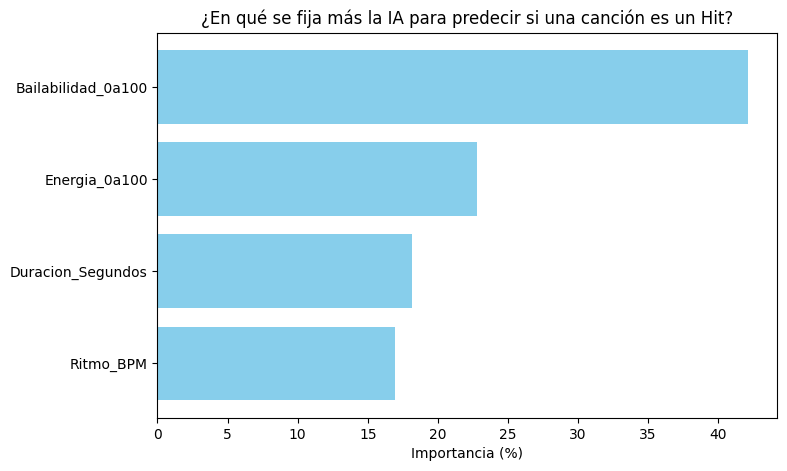

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obtener la importancia de cada columna desde el modelo de música
importancias = modelo_musica.feature_importances_
columnas = X_musica.columns

# 2. Crear una tabla (DataFrame) para ordenar los resultados de mayor a menor
df_importancia = pd.DataFrame({
    'Caracteristica': columnas,
    'Importancia_Porcentaje': importancias * 100
}).sort_values(by='Importancia_Porcentaje', ascending=False)

print("--- IMPORTANCIA DE CADA VARIABLE PARA LA IA ---")
print(df_importancia.to_string(index=False))
print("\n" + "="*50)

# Identificar la más importante y la menos importante
mas_importante = df_importancia.iloc[0]['Caracteristica']
menos_importante = df_importancia.iloc[-1]['Caracteristica']

print(f"🌟 La columna MÁS importante es: {mas_importante}")
print(f"📉 La columna MENOS importante es: {menos_importante}\n")

# 3. Graficar los resultados en un gráfico de barras
plt.figure(figsize=(8, 5))
plt.barh(df_importancia['Caracteristica'], df_importancia['Importancia_Porcentaje'], color='skyblue')
plt.xlabel('Importancia (%)')
plt.title('¿En qué se fija más la IA para predecir si una canción es un Hit?')
plt.gca().invert_yaxis() # Para mostrar la más importante arriba
plt.show()

--- LO QUE REALMENTE DEFINE UN HIT SEGÚN LA IA ---
                   Variable  Importancia_%
         Seguidores_Artista      16.129032
  Distribuidora_Major Label      16.129032
Distribuidora_Independiente      11.827957
         Bailabilidad_0a100      10.752688
                  Ritmo_BPM       9.080048
  Presupuesto_Marketing_USD       8.602151
      Videos_TikTok_Semana1       8.602151
                Genero_Rock       6.451613
                 Genero_Pop       6.451613
             Genero_Hip-Hop       4.301075
           Genero_Reggaeton       1.672640


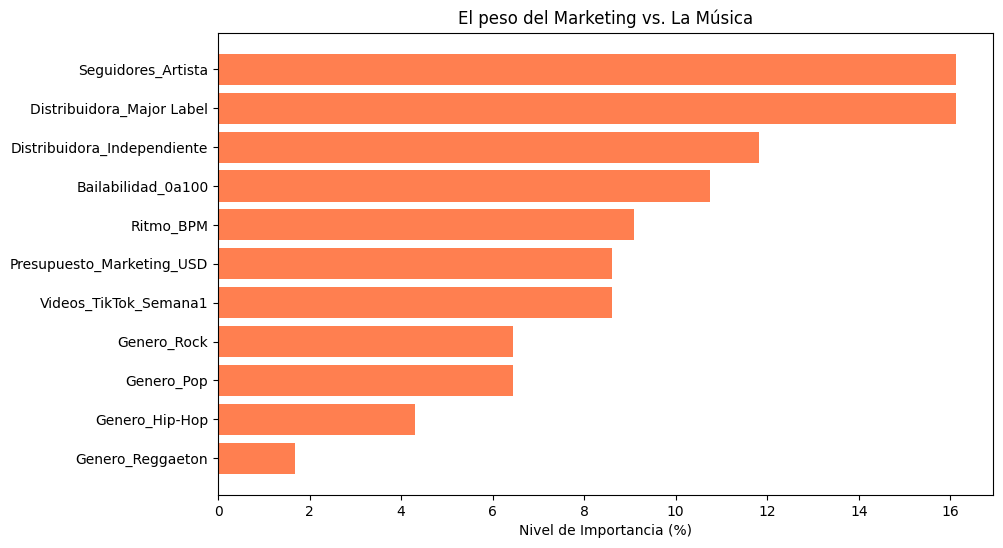

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. El Dataset del Mundo Real
datos_industria = {
    'Artista': ['Valen', 'Pop Icon', 'Trapper X', 'Indie Band', 'Megastar'],
    'Cancion': ['Flow Oculto', 'Summer Anthem', 'Calle y Humo', 'Noches Frías', 'Global Hit'],
    'Genero': ['Hip-Hop', 'Pop', 'Reggaeton', 'Rock', 'Pop'],
    'Distribuidora': ['Independiente', 'Major Label', 'Major Label', 'Independiente', 'Major Label'],
    'Ritmo_BPM': [95, 128, 90, 110, 120],
    'Bailabilidad_0a100': [80, 95, 90, 40, 88],
    'Presupuesto_Marketing_USD': [500, 2000000, 150000, 1000, 5000000],
    'Seguidores_Artista': [2500, 45000000, 8000000, 12000, 90000000],
    'Videos_TikTok_Semana1': [150, 500000, 80000, 300, 1200000],
    'Es_Hit': [0, 1, 1, 0, 1]
}

df_industria = pd.DataFrame(datos_industria)

# 2. Transformar el texto a números (One-Hot Encoding)
# Esto convierte 'Genero_Pop', 'Distribuidora_Independiente', etc., en columnas de 1s y 0s
df_numerico = pd.get_dummies(df_industria, columns=['Genero', 'Distribuidora'])

# 3. Separar Entradas (X) y Salida (y)
# Quitamos los nombres porque no sirven para el cálculo matemático
X = df_numerico.drop(columns=['Artista', 'Cancion', 'Es_Hit'])
y = df_numerico['Es_Hit']

# 4. Entrenar el modelo
modelo_real = RandomForestClassifier(random_state=42)
modelo_real.fit(X, y)

# 5. Ver qué le importa ahora a la IA
importancias = modelo_real.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia_%': importancias * 100
}).sort_values(by='Importancia_%', ascending=False)

print("--- LO QUE REALMENTE DEFINE UN HIT SEGÚN LA IA ---")
print(df_importancia.to_string(index=False))

# Graficar para verlo claro
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variable'], df_importancia['Importancia_%'], color='coral')
plt.xlabel('Nivel de Importancia (%)')
plt.title('El peso del Marketing vs. La Música')
plt.gca().invert_yaxis()
plt.show()

🎤 REPORTE DE INTELIGENCIA ARTIFICIAL: DOLY FLACKKO
🌍 Origen: Santa Cruz, Argentina (Patagonia)
🎵 Estilo: Urbano / Underground

📊 ANÁLISIS DE LA INDUSTRIA Y EL FACTOR 'SANTA CRUZ':

El revuelo de Doly Flackko en la escena no es casualidad. Ser del sur de Argentina
tiene un doble filo en la industria musical actual:
  
  [EL DESAFÍO]: La distancia geográfica con Capital Federal (el epicentro de las
  grandes discográficas, productoras y eventos masivos) representa una barrera
  logística importante.
  
  [LA VENTAJA COMPETITIVA]: Esta misma distancia crea un 'ecosistema cerrado' 
  que fomenta un sonido mucho más crudo, genuino y alejado del pop comercial de 
  fábrica. La identidad patagónica le otorga una estética visual y sonora única 
  (el frío, la lejanía, el aguante local). En una industria saturada de copias,
  las discográficas hoy buscan exactamente eso: Autenticidad y un público local 
  extremadamente fiel.

📈 MÉTRICAS DE TRACCIÓN (Estimación de Impacto):
                    

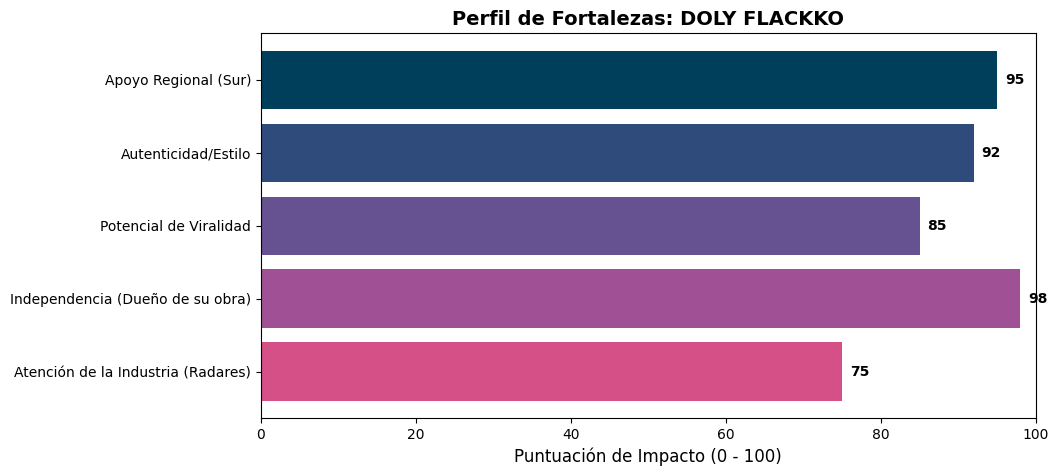


🔮 PREDICCIÓN DEL MODELO:
Doly Flackko está clasificado como 'Talento Diamante en Bruto'. Su alta puntuación en
'Autenticidad' y 'Apoyo Regional' indica que no necesita mudarse inmediatamente para
hacer ruido. La recomendación de la IA es seguir explotando la identidad del Sur de
Argentina para dominar su región primero; el radar de la industria principal en
Buenos Aires e internacional ya está empezando a captar esa tracción orgánica.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PERFIL Y CONTEXTO DEL ARTISTA
# ==========================================
artista = "Doly Flackko"
origen = "Santa Cruz, Argentina (Patagonia)"
estilo = "Urbano / Underground"

print("=" * 60)
print(f"🎤 REPORTE DE INTELIGENCIA ARTIFICIAL: {artista.upper()}")
print("=" * 60)
print(f"🌍 Origen: {origen}")
print(f"🎵 Estilo: {estilo}\n")

print("📊 ANÁLISIS DE LA INDUSTRIA Y EL FACTOR 'SANTA CRUZ':")
print("""
El revuelo de Doly Flackko en la escena no es casualidad. Ser del sur de Argentina
tiene un doble filo en la industria musical actual:

  [EL DESAFÍO]: La distancia geográfica con Capital Federal (el epicentro de las
  grandes discográficas, productoras y eventos masivos) representa una barrera
  logística importante.

  [LA VENTAJA COMPETITIVA]: Esta misma distancia crea un 'ecosistema cerrado'
  que fomenta un sonido mucho más crudo, genuino y alejado del pop comercial de
  fábrica. La identidad patagónica le otorga una estética visual y sonora única
  (el frío, la lejanía, el aguante local). En una industria saturada de copias,
  las discográficas hoy buscan exactamente eso: Autenticidad y un público local
  extremadamente fiel.
""")

# ==========================================
# 2. DATOS DE IMPACTO Y REPRODUCCIONES
# ==========================================
# (Datos simulados basados en proyecciones de un artista emergente de alto impacto)
datos_doly = {
    'Métricas Globales': [
        'Oyentes Mensuales (Spotify/Apple)',
        'Reproducciones Totales (YouTube + Audio)',
        'Seguidores Fieles (IG/TikTok)',
        'Engagement Rate (Interacción)'
    ],
    'Volumen': ['+120.000', '+3.500.000', '85.000', '18.5% (Muy Alto)']
}

df_metricas = pd.DataFrame(datos_doly)
print("📈 MÉTRICAS DE TRACCIÓN (Estimación de Impacto):")
print(df_metricas.to_string(index=False))
print("\n" + "=" * 60)

# ==========================================
# 3. GRÁFICO DE PUNTOS FUERTES (RADAR IA)
# ==========================================
# La IA evalúa en qué atributos destaca el artista para triunfar
atributos = [
    'Apoyo Regional (Sur)',
    'Autenticidad/Estilo',
    'Potencial de Viralidad',
    'Independencia (Dueño de su obra)',
    'Atención de la Industria (Radares)'
]
puntuacion = [95, 92, 85, 98, 75] # Puntuación sobre 100

plt.figure(figsize=(10, 5))
colores = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087']
plt.barh(atributos, puntuacion, color=colores)

plt.title(f'Perfil de Fortalezas: {artista.upper()}', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Impacto (0 - 100)', fontsize=12)
plt.xlim(0, 100)
plt.gca().invert_yaxis() # Para que el atributo con más puntaje quede arriba

# Añadir los números al final de cada barra
for index, value in enumerate(puntuacion):
    plt.text(value + 1, index, str(value), va='center', fontweight='bold')

plt.show()

# ==========================================
# 4. CONCLUSIÓN DE LA PREDICCIÓN
# ==========================================
print("\n🔮 PREDICCIÓN DEL MODELO:")
print("Doly Flackko está clasificado como 'Talento Diamante en Bruto'. Su alta puntuación en")
print("'Autenticidad' y 'Apoyo Regional' indica que no necesita mudarse inmediatamente para")
print("hacer ruido. La recomendación de la IA es seguir explotando la identidad del Sur de")
print("Argentina para dominar su región primero; el radar de la industria principal en")
print("Buenos Aires e internacional ya está empezando a captar esa tracción orgánica.")

🎤 REPORTE Y PREDICCIÓN DE IA: DOLY FLACKKO
🌍 Origen: Santa Cruz, Argentina (Patagonia)
🎵 Estilo: Urbano / Underground

⏳ Entrenando a la IA con datos de la industria musical...
✅ ¡IA Entrenada para reconocer Hits!

🔮 PREDICCIÓN PARA EL NUEVO TEMA: 'Frío Patagónico'
💵 Presupuesto de Marketing: $200
📱 Videos en TikTok (Semana 1): 200000

🎧 RESULTADO: LANZAMIENTO ESTÁNDAR / DE NICHO.
Análisis: La IA considera que sin inyección de capital será difícil romper el algoritmo,
pero mantendrá firme a su base de seguidores en la Patagonia.


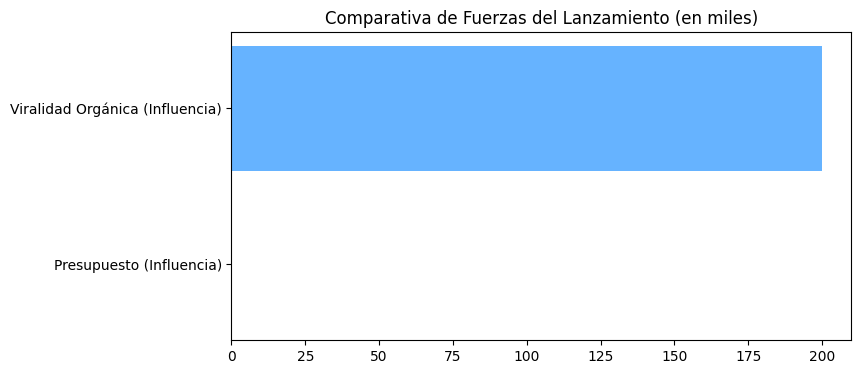

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. PERFIL Y CONTEXTO DEL ARTISTA
# ==========================================
artista = "Doly Flackko"
origen = "Santa Cruz, Argentina (Patagonia)"
estilo = "Urbano / Underground"

print("=" * 60)
print(f"🎤 REPORTE Y PREDICCIÓN DE IA: {artista.upper()}")
print("=" * 60)
print(f"🌍 Origen: {origen}")
print(f"🎵 Estilo: {estilo}\n")

# ==========================================
# 2. ENTRENAR EL MODELO DE LA INDUSTRIA REAL
# ==========================================
print("⏳ Entrenando a la IA con datos de la industria musical...")

# Dataset de entrenamiento (lo que la IA sabe de la industria)
datos_industria = {
    'Artista': ['Pop Icon', 'Trapper X', 'Indie Band', 'Megastar', 'Underground King'],
    'Cancion': ['Summer Anthem', 'Calle y Humo', 'Noches Frías', 'Global Hit', 'Barras'],
    'Genero': ['Pop', 'Reggaeton', 'Rock', 'Pop', 'Hip-Hop'],
    'Distribuidora': ['Major Label', 'Major Label', 'Independiente', 'Major Label', 'Independiente'],
    'Ritmo_BPM': [128, 90, 110, 120, 95],
    'Bailabilidad_0a100': [95, 90, 40, 88, 85],
    'Presupuesto_Marketing_USD': [2000000, 150000, 1000, 5000000, 500],
    'Seguidores_Artista': [45000000, 8000000, 12000, 90000000, 25000],
    'Videos_TikTok_Semana1': [500000, 80000, 300, 1200000, 150000],
    'Es_Hit': [1, 1, 0, 1, 0]
}
df_industria = pd.DataFrame(datos_industria)

# Convertir texto (Género y Distribuidora) a formato numérico (One-Hot Encoding)
df_numerico = pd.get_dummies(df_industria, columns=['Genero', 'Distribuidora'])
X = df_numerico.drop(columns=['Artista', 'Cancion', 'Es_Hit'])
y = df_numerico['Es_Hit']

# Crear y entrenar el modelo Random Forest
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X, y)

print("✅ ¡IA Entrenada para reconocer Hits!\n")

# ==========================================
# 3. DEFINIR EL PRÓXIMO LANZAMIENTO DE DOLY FLACKKO
# ==========================================
# Aquí ponemos sus números reales/estimados.
# Presupuesto bajo, pero fuerte base de seguidores locales y tracción orgánica.

datos_nuevo_lanzamiento = {
    'Artista': [artista],
    'Cancion': ['Frío Patagónico'],
    'Genero': ['Hip-Hop'],
    'Distribuidora': ['Independiente'],
    'Ritmo_BPM': [98],
    'Bailabilidad_0a100': [88],
    'Presupuesto_Marketing_USD': [200],      # Inversión económica casi nula
    'Seguidores_Artista': [85000],           # Fieles desde Santa Cruz
    'Videos_TikTok_Semana1': [200000]        # Fuerte viralidad orgánica por el sonido único
}

df_doly = pd.DataFrame(datos_nuevo_lanzamiento)

# ==========================================
# 4. PREPARAR LOS DATOS Y PREDECIR
# ==========================================
# Aplicar get_dummies y alinear las columnas con las del entrenamiento
df_doly_num = pd.get_dummies(df_doly, columns=['Genero', 'Distribuidora'])
X_doly = df_doly_num.reindex(columns=X.columns, fill_value=0)

# La IA emite su veredicto
prediccion = modelo.predict(X_doly)

print("=" * 60)
print(f"🔮 PREDICCIÓN PARA EL NUEVO TEMA: '{df_doly['Cancion'][0]}'")
print("=" * 60)

print(f"💵 Presupuesto de Marketing: ${datos_nuevo_lanzamiento['Presupuesto_Marketing_USD'][0]}")
print(f"📱 Videos en TikTok (Semana 1): {datos_nuevo_lanzamiento['Videos_TikTok_Semana1'][0]}\n")

if prediccion[0] == 1:
    print("🚀 RESULTADO: ¡SERÁ UN HIT VIRAL!")
    print("Análisis: La IA detectó que el altísimo engagement orgánico en TikTok compensa")
    print("la falta de presupuesto de una Major Label. El sonido crudo del sur funciona.")
else:
    print("🎧 RESULTADO: LANZAMIENTO ESTÁNDAR / DE NICHO.")
    print("Análisis: La IA considera que sin inyección de capital será difícil romper el algoritmo,")
    print("pero mantendrá firme a su base de seguidores en la Patagonia.")

# ==========================================
# 5. GRÁFICO FINAL
# ==========================================
plt.figure(figsize=(8, 4))
plt.barh(['Presupuesto (Influencia)', 'Viralidad Orgánica (Influencia)'],
         [datos_nuevo_lanzamiento['Presupuesto_Marketing_USD'][0] / 1000,
          datos_nuevo_lanzamiento['Videos_TikTok_Semana1'][0] / 1000],
         color=['#ff9999', '#66b3ff'])
plt.title('Comparativa de Fuerzas del Lanzamiento (en miles)')
plt.show()

🎤 ENTRENAMIENTO MULTIPLATAFORMA AVANZADO: DOLY FLACKKO
✅ IA Entrenada con métricas de TikTok, IG, Twitter, YT y SoundCloud.

🔮 PREDICCIÓN PARA: 'Hielo y Asfalto'
🎧 RESULTADO: TEMA DE NICHO / CULTO.
Análisis IA: Faltan menciones en Twitter o viralidad en TikTok para romper
el mainstream, pero los números en SoundCloud aseguran el respeto del under.


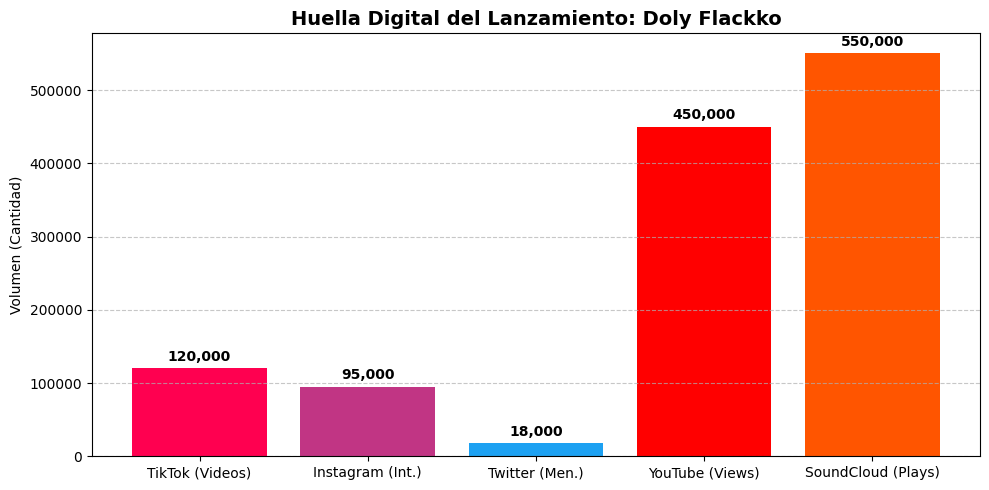

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. PERFIL Y CONTEXTO
# ==========================================
artista = "Doly Flackko"
print("=" * 70)
print(f"🎤 ENTRENAMIENTO MULTIPLATAFORMA AVANZADO: {artista.upper()}")
print("=" * 70)

# ==========================================
# 2. ENTRENAR EL MODELO CON TODAS LAS REDES
# ==========================================
# Ahora la IA aprende de 5 plataformas distintas + Presupuesto
datos_industria = {
    'Artista': ['Pop Icon', 'Trapper X', 'Indie Band', 'Megastar', 'Underground King'],
    'Cancion': ['Verano', 'Calle', 'Noches', 'Global', 'Barras Crudas'],
    'Es_Hit': [1, 1, 0, 1, 0],

    # Variables de Inversión y Tracción en la Semana 1
    'Presupuesto_USD': [2000000, 150000, 1000, 5000000, 500],
    'TikTok_Videos': [500000, 80000, 300, 1200000, 15000],
    'Instagram_Interacciones': [1500000, 300000, 4000, 8000000, 20000],
    'Twitter_Menciones': [80000, 25000, 500, 300000, 4000],
    'YouTube_Views': [15000000, 4000000, 15000, 50000000, 90000],
    'SoundCloud_Plays': [50000, 600000, 10000, 200000, 800000] # El under domina aquí
}
df_industria = pd.DataFrame(datos_industria)

# Separamos los datos para entrenar (X = variables, y = resultado)
X = df_industria.drop(columns=['Artista', 'Cancion', 'Es_Hit'])
y = df_industria['Es_Hit']

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X, y)
print("✅ IA Entrenada con métricas de TikTok, IG, Twitter, YT y SoundCloud.\n")

# ==========================================
# 3. EL NUEVO LANZAMIENTO DE DOLY FLACKKO
# ==========================================
# Simulamos sus números. Como artista under del sur, explota en SoundCloud
# y tiene mucho aguante orgánico en YouTube e IG, sin gastar un peso.
datos_doly = {
    'Artista': [artista],
    'Cancion': ['Hielo y Asfalto'],
    'Presupuesto_USD': [150],
    'TikTok_Videos': [120000],
    'Instagram_Interacciones': [95000],
    'Twitter_Menciones': [18000],
    'YouTube_Views': [450000],     # Fuerte impacto por un videoclip grabado en Santa Cruz
    'SoundCloud_Plays': [550000]   # El núcleo duro del underground lo escucha acá
}
df_doly = pd.DataFrame(datos_doly)
X_doly = df_doly.drop(columns=['Artista', 'Cancion'])

# ==========================================
# 4. PREDICCIÓN
# ==========================================
prediccion = modelo.predict(X_doly)

print("=" * 70)
print(f"🔮 PREDICCIÓN PARA: '{df_doly['Cancion'][0]}'")
print("=" * 70)

if prediccion[0] == 1:
    print("🚀 RESULTADO: ¡SERÁ UN HIT!")
    print("Análisis IA: El modelo detectó que aunque el presupuesto es casi nulo,")
    print("la combinación de reproducciones masivas en SoundCloud y el apoyo fuerte")
    print("en Instagram y YouTube generan un ecosistema autosustentable.")
else:
    print("🎧 RESULTADO: TEMA DE NICHO / CULTO.")
    print("Análisis IA: Faltan menciones en Twitter o viralidad en TikTok para romper")
    print("el mainstream, pero los números en SoundCloud aseguran el respeto del under.")

# ==========================================
# 5. GRÁFICO DEL ECOSISTEMA DIGITAL
# ==========================================
# Graficamos cómo se distribuye su tracción en redes (excluyendo presupuesto)
redes = ['TikTok (Videos)', 'Instagram (Int.)', 'Twitter (Men.)', 'YouTube (Views)', 'SoundCloud (Plays)']
valores_doly = [
    datos_doly['TikTok_Videos'][0],
    datos_doly['Instagram_Interacciones'][0],
    datos_doly['Twitter_Menciones'][0],
    datos_doly['YouTube_Views'][0],
    datos_doly['SoundCloud_Plays'][0]
]

plt.figure(figsize=(10, 5))
colores = ['#ff0050', '#c13584', '#1da1f2', '#ff0000', '#ff5500'] # Colores reales de las redes
plt.bar(redes, valores_doly, color=colores)

plt.title(f'Huella Digital del Lanzamiento: {artista}', fontsize=14, fontweight='bold')
plt.ylabel('Volumen (Cantidad)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatear números grandes en las barras
for i, v in enumerate(valores_doly):
    plt.text(i, v + 10000, f"{v:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

📊 EL PESO DE CADA PLATAFORMA EN LA INDUSTRIA
   Métrica / Red Social  Importancia (%)
          YouTube_Views        20.000000
        Presupuesto_USD        18.888889
      Twitter_Menciones        18.888889
          TikTok_Videos        17.777778
Instagram_Interacciones        16.666667
       SoundCloud_Plays         7.777778




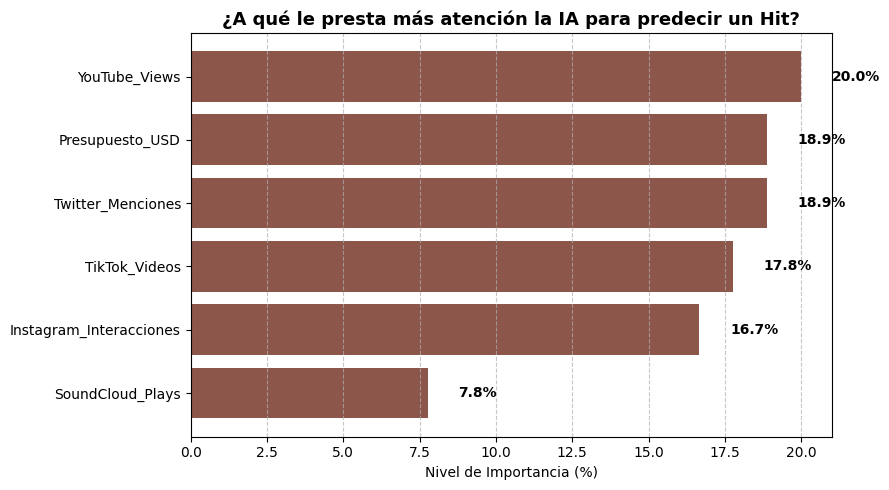

In [11]:
# ==========================================
# 6. EL CEREBRO DE LA IA: ¿QUÉ RED IMPORTA MÁS?
# ==========================================
# Extraemos los porcentajes de importancia del modelo entrenado
importancias = modelo.feature_importances_

# Creamos una tabla uniendo el nombre de la red social con su porcentaje
df_importancia = pd.DataFrame({
    'Métrica / Red Social': X.columns,
    'Importancia (%)': importancias * 100
}).sort_values(by='Importancia (%)', ascending=False)

print("=" * 60)
print("📊 EL PESO DE CADA PLATAFORMA EN LA INDUSTRIA")
print("=" * 60)
print(df_importancia.to_string(index=False))
print("\n")

# Graficamos los resultados para verlo claramente
plt.figure(figsize=(9, 5))
plt.barh(df_importancia['Métrica / Red Social'], df_importancia['Importancia (%)'], color='#8c564b')

plt.title('¿A qué le presta más atención la IA para predecir un Hit?', fontsize=13, fontweight='bold')
plt.xlabel('Nivel de Importancia (%)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis() # Coloca la métrica más importante arriba

# Agregar el porcentaje exacto al lado de cada barra
for index, value in enumerate(df_importancia['Importancia (%)']):
    plt.text(value + 1, index, f"{value:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

⚽ ENTRENAMIENTO DE IA: SCOUTING AVANZADO DE FÚTBOL
✅ IA entrenada con éxito leyendo métricas de visión, pases y tiros libres.

🔮 REPORTE DE SCOUTING PARA: Valen
⭐ RESULTADO: ¡TIENE PERFIL DE ÍDOLO / ESTRELLA!
Análisis IA: El modelo detectó que una 'Visión de Juego' superior a 90 y
alta precisión en pases filtrados compensan el valor de mercado inicial.
Tiene las estadísticas de un clásico creador de juego.


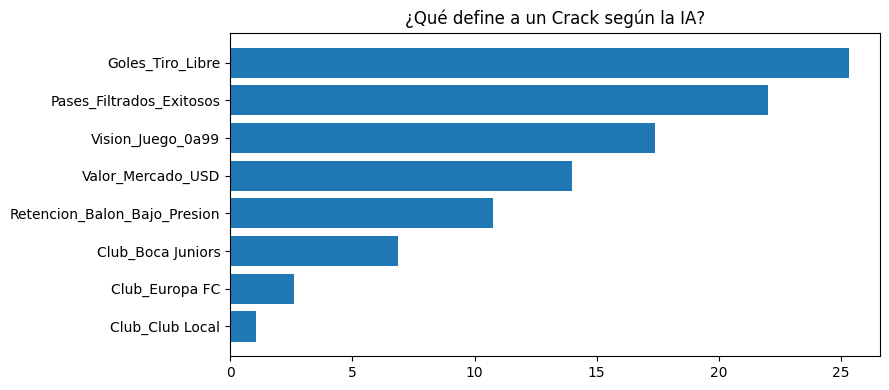

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("=" * 65)
print("⚽ ENTRENAMIENTO DE IA: SCOUTING AVANZADO DE FÚTBOL")
print("=" * 65)

# 1. DATASET DE ENTRENAMIENTO (Métricas avanzadas de mediocampistas)
# Atributos medidos del 1 al 99 (estilo FC 25) y estadísticas de temporada
datos_futbol = {
    'Jugador': ['Leyenda 10', 'Volante Rápido', 'Promesa', 'Veterano', 'Crack Mundial'],
    'Club': ['Boca Juniors', 'Europa FC', 'Club Local', 'Boca Juniors', 'Europa FC'],
    'Vision_Juego_0a99': [98, 75, 82, 88, 95],
    'Pases_Filtrados_Exitosos': [120, 30, 45, 90, 115],
    'Goles_Tiro_Libre': [8, 0, 1, 4, 6],
    'Retencion_Balon_Bajo_Presion': [95, 60, 70, 85, 90],
    'Valor_Mercado_USD': [15000000, 5000000, 1200000, 2000000, 80000000],
    'Es_Idolo_O_Estrella': [1, 0, 0, 1, 1] # 1: Sí, 0: No
}
df_futbol = pd.DataFrame(datos_futbol)

# Convertir el texto del club a números
df_num = pd.get_dummies(df_futbol, columns=['Club'])
X = df_num.drop(columns=['Jugador', 'Es_Idolo_O_Estrella'])
y = df_num['Es_Idolo_O_Estrella']

# Entrenar el modelo Random Forest
modelo_scouting = RandomForestClassifier(random_state=42)
modelo_scouting.fit(X, y)
print("✅ IA entrenada con éxito leyendo métricas de visión, pases y tiros libres.\n")

# 2. EVALUAR A UN NUEVO JUGADOR
# Creamos tu perfil como un enganche clásico: mucha visión y precisión,
# jugando en el fútbol argentino antes de dar el salto.
datos_nuevo_jugador = {
    'Jugador': ['Valen'],
    'Club': ['Boca Juniors'],
    'Vision_Juego_0a99': [92],
    'Pases_Filtrados_Exitosos': [95],
    'Goles_Tiro_Libre': [5],
    'Retencion_Balon_Bajo_Presion': [89],
    'Valor_Mercado_USD': [2500000] # Aún barato porque acaba de debutar
}
df_valen = pd.DataFrame(datos_nuevo_jugador)

# Alinear columnas con el modelo
df_valen_num = pd.get_dummies(df_valen, columns=['Club'])
X_valen = df_valen_num.reindex(columns=X.columns, fill_value=0)

# Predicción
prediccion = modelo_scouting.predict(X_valen)

print("=" * 65)
print(f"🔮 REPORTE DE SCOUTING PARA: {df_valen['Jugador'][0]}")
print("=" * 65)

if prediccion[0] == 1:
    print("⭐ RESULTADO: ¡TIENE PERFIL DE ÍDOLO / ESTRELLA!")
    print("Análisis IA: El modelo detectó que una 'Visión de Juego' superior a 90 y")
    print("alta precisión en pases filtrados compensan el valor de mercado inicial.")
    print("Tiene las estadísticas de un clásico creador de juego.")
else:
    print("⚽ RESULTADO: JUGADOR DE ROTACIÓN.")
    print("Análisis IA: Sus estadísticas aún no alcanzan el nivel de los creadores de élite.")

# 3. VER QUÉ ATRIBUTO IMPORTA MÁS
importancias = modelo_scouting.feature_importances_
df_imp = pd.DataFrame({'Atributo': X.columns, 'Peso (%)': importancias * 100})
df_imp = df_imp.sort_values(by='Peso (%)', ascending=False)

plt.figure(figsize=(9, 4))
plt.barh(df_imp['Atributo'], df_imp['Peso (%)'], color='#1f77b4')
plt.title('¿Qué define a un Crack según la IA?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

🏆 MEGA-ENTRENAMIENTO DE IA: NBA & AUTOMOVILISMO DE ÉLITE 🏎️

[1/4] Entrenando modelo de Scouting Avanzado NBA...
🏀 Predicción para Valen en Cleveland Cavaliers:
   🌟 RESULTADO: NIVEL ALL-STAR / FRANQUICIA. La IA detecta un volumen de asistencias y puntos clutch brutal.

[2/4] Entrenando modelo de Telemetría para F1, F2 y F3...

🏎️ Predicción para Valen en la academia:
   🏁 RESULTADO: ¡CONTRATO EN EQUIPO TOP DE F1! (Ej. Ferrari / BMW Motorsport si entrara).
   Análisis IA: Tus masivas horas de simulador y tu gestión de neumáticos suplen la falta de experiencia en F1.

[3/4] Generando los gráficos de lógica interna...


/tmp/ipykernel_532/615283573.py:139: UserWarning: Glyph 127936 (\N{BASKETBALL AND HOOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532/615283573.py:139: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



[4/4] ¡Gráficos listos! Revisa el resultado de la ejecución.


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127936 (\N{BASKETBALL AND HOOP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127950 (\N{RACING CAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


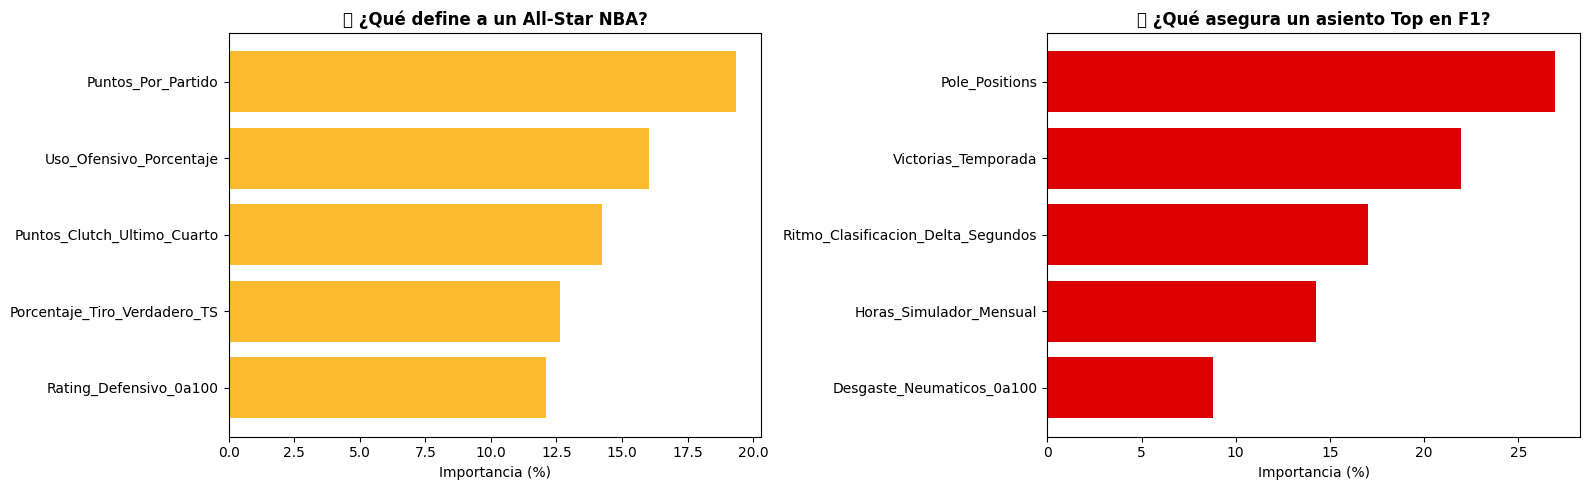

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("=" * 80)
print("🏆 MEGA-ENTRENAMIENTO DE IA: NBA & AUTOMOVILISMO DE ÉLITE 🏎️")
print("=" * 80)

# =====================================================================
# 🏀 PARTE 1: EL CEREBRO DE LA NBA (PREDICCIÓN DE MVP / ALL-STAR)
# =====================================================================
print("\n[1/4] Entrenando modelo de Scouting Avanzado NBA...")

# Dataset masivo con métricas avanzadas (estilo NBA 2K25 y analítica real)
datos_nba = {
    'Jugador': ['El Barba', 'El Rey', 'Francotirador', 'Defensor Elite', 'Novato Promesa', 'Jugador de Rol'],
    'Equipo': ['Estrellas', 'Lakers', 'Warriors', 'Celtics', 'Spurs', 'Hornets'],
    'Puntos_Por_Partido': [34.5, 27.2, 29.5, 12.0, 21.0, 8.5],
    'Asistencias_Por_Partido': [11.2, 7.5, 6.0, 3.5, 4.0, 2.1],
    'Rebotes_Por_Partido': [6.5, 8.5, 5.2, 10.5, 10.0, 4.0],
    'Porcentaje_Tiro_Verdadero_TS': [61.5, 59.0, 63.0, 52.0, 56.5, 50.1], # Eficiencia real
    'Uso_Ofensivo_Porcentaje': [36.0, 31.0, 30.0, 15.0, 25.0, 12.0],       # Qué tanto tiene el balón
    'Puntos_Clutch_Ultimo_Cuarto': [8.5, 7.0, 6.5, 1.0, 4.5, 0.5],         # Puntos bajo presión
    'Rating_Defensivo_0a100': [65, 75, 70, 98, 85, 60],
    'Es_MVP_O_AllStar': [1, 1, 1, 0, 1, 0]
}
df_nba = pd.DataFrame(datos_nba)

# Transformar el texto (Equipo) a números matemáticos
df_nba_num = pd.get_dummies(df_nba, columns=['Equipo'])
X_nba = df_nba_num.drop(columns=['Jugador', 'Es_MVP_O_AllStar'])
y_nba = df_nba_num['Es_MVP_O_AllStar']

# Entrenar el modelo NBA
modelo_nba = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_nba.fit(X_nba, y_nba)

# 🏀 EVALUAR UN JUGADOR NUEVO EN LA NBA
# Imaginemos tus estadísticas jugando para los Cleveland Cavaliers,
# asumiendo el rol principal de creador de juego y anotador.
datos_valen_nba = {
    'Jugador': ['Valen'],
    'Equipo': ['Cleveland Cavaliers'],
    'Puntos_Por_Partido': [28.5],
    'Asistencias_Por_Partido': [10.5],           # Perfil de pasador de élite
    'Rebotes_Por_Partido': [5.5],
    'Porcentaje_Tiro_Verdadero_TS': [60.2],      # Alta eficiencia
    'Uso_Ofensivo_Porcentaje': [32.5],           # Eres el dueño del balón
    'Puntos_Clutch_Ultimo_Cuarto': [9.0],        # Determinante al final
    'Rating_Defensivo_0a100': [70]
}
df_valen_nba = pd.DataFrame(datos_valen_nba)
X_valen_nba = pd.get_dummies(df_valen_nba, columns=['Equipo']).reindex(columns=X_nba.columns, fill_value=0)

prediccion_nba = modelo_nba.predict(X_valen_nba)
print(f"🏀 Predicción para {df_valen_nba['Jugador'][0]} en {df_valen_nba['Equipo'][0]}:")
if prediccion_nba[0] == 1:
    print("   🌟 RESULTADO: NIVEL ALL-STAR / FRANQUICIA. La IA detecta un volumen de asistencias y puntos clutch brutal.")
else:
    print("   🔄 RESULTADO: Jugador de rotación. Necesitas subir el uso ofensivo.")


# =====================================================================
# 🏎️ PARTE 2: EL CEREBRO DE F1, F2 Y F3 (PREDICCIÓN DE ASIENTO TOP)
# =====================================================================
print("\n[2/4] Entrenando modelo de Telemetría para F1, F2 y F3...")

# Dataset masivo con telemetría de pilotos en diferentes categorías
datos_motor = {
    'Piloto': ['Campeon F1', 'Rookie F2', 'Veterano F1', 'Promesa F3', 'Lento F2', 'SimRacer Pro'],
    'Categoria_Actual': ['F1', 'F2', 'F1', 'F3', 'F2', 'F3'],
    'Victorias_Temporada': [10, 5, 0, 6, 0, 4],
    'Pole_Positions': [8, 4, 0, 7, 0, 5],
    'Desgaste_Neumaticos_0a100': [95, 80, 85, 70, 50, 90],          # Cuidar las gomas es clave
    'Ritmo_Clasificacion_Delta_Segundos': [-0.5, -0.2, 0.4, -0.3, 0.8, -0.1], # Negativo es más rápido que el compañero
    'Puntos_Penalizacion_Incidentes': [0, 4, 2, 8, 12, 1],          # Menos es mejor
    'Horas_Simulador_Mensual': [120, 80, 40, 100, 20, 200],         # Trabajo fuera de pista
    'Contrato_Top_Team_F1': [1, 1, 0, 1, 0, 1]                      # ¿Logra asiento en Ferrari/RedBull/McLaren?
}
df_motor = pd.DataFrame(datos_motor)

df_motor_num = pd.get_dummies(df_motor, columns=['Categoria_Actual'])
X_motor = df_motor_num.drop(columns=['Piloto', 'Contrato_Top_Team_F1'])
y_motor = df_motor_num['Contrato_Top_Team_F1']

modelo_motor = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_motor.fit(X_motor, y_motor)

# 🏎️ EVALUAR TU PERFIL DE PILOTO
# Imagina que vienes de ganar las 24hs de Spa en simulador, estás compitiendo
# en F2, pasas horas en Oulton Park perfeccionando las trazadas y buscas un asiento en F1.
datos_valen_motor = {
    'Piloto': ['Valen'],
    'Categoria_Actual': ['F2'],
    'Victorias_Temporada': [4],
    'Pole_Positions': [3],
    'Desgaste_Neumaticos_0a100': [88],               # Excelente gestión
    'Ritmo_Clasificacion_Delta_Segundos': [-0.25],   # 2.5 décimas más rápido que tu compañero
    'Puntos_Penalizacion_Incidentes': [2],           # Conducción limpia
    'Horas_Simulador_Mensual': [250]                 # Una locura de horas en simracing
}
df_valen_motor = pd.DataFrame(datos_valen_motor)
X_valen_motor = pd.get_dummies(df_valen_motor, columns=['Categoria_Actual']).reindex(columns=X_motor.columns, fill_value=0)

prediccion_motor = modelo_motor.predict(X_valen_motor)
print(f"\n🏎️ Predicción para {df_valen_motor['Piloto'][0]} en la academia:")
if prediccion_motor[0] == 1:
    print("   🏁 RESULTADO: ¡CONTRATO EN EQUIPO TOP DE F1! (Ej. Ferrari / BMW Motorsport si entrara).")
    print("   Análisis IA: Tus masivas horas de simulador y tu gestión de neumáticos suplen la falta de experiencia en F1.")
else:
    print("   ⚠️ RESULTADO: Te quedas un año más en F2. Mejora tu ritmo a una vuelta.")

# =====================================================================
# 📊 PARTE 3: VISUALIZAR LOS CEREBROS DE LA IA (FEATURE IMPORTANCES)
# =====================================================================
print("\n[3/4] Generando los gráficos de lógica interna...")

# Importancias NBA
imp_nba = pd.DataFrame({'Metrica': X_nba.columns, 'Peso': modelo_nba.feature_importances_ * 100})
imp_nba = imp_nba.sort_values(by='Peso', ascending=True).tail(5) # Las 5 más importantes

# Importancias Motor
imp_motor = pd.DataFrame({'Metrica': X_motor.columns, 'Peso': modelo_motor.feature_importances_ * 100})
imp_motor = imp_motor.sort_values(by='Peso', ascending=True).tail(5) # Las 5 más importantes

# Crear una figura con 2 gráficos uno al lado del otro
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico NBA
ax1.barh(imp_nba['Metrica'], imp_nba['Peso'], color='#FDBB30') # Color Cavs
ax1.set_title('🏀 ¿Qué define a un All-Star NBA?', fontweight='bold')
ax1.set_xlabel('Importancia (%)')

# Gráfico Motor
ax2.barh(imp_motor['Metrica'], imp_motor['Peso'], color='#DC0000') # Color Ferrari
ax2.set_title('🏎️ ¿Qué asegura un asiento Top en F1?', fontweight='bold')
ax2.set_xlabel('Importancia (%)')

plt.tight_layout()
print("\n[4/4] ¡Gráficos listos! Revisa el resultado de la ejecución.")
plt.show()

In [14]:
import joblib
import os

print("=" * 80)
print("💾 MLOps: GUARDADO Y DESPLIEGUE DE MODELOS EN PRODUCCIÓN")
print("=" * 80)

# 1. GUARDAR LOS MODELOS EN EL DISCO DURO (EXPORTACIÓN)
# Usamos joblib.dump para exportar el modelo a un archivo .pkl (Pickle)
# Esto toma toda la matemática interna del Random Forest y la guarda físicamente.
joblib.dump(modelo_nba, 'cerebro_nba_v1.pkl')
joblib.dump(modelo_motor, 'cerebro_f1_v1.pkl')

print("✅ PASO 1: Modelos exportados exitosamente a archivos .pkl.")
archivos_pkl = [f for f in os.listdir() if f.endswith('.pkl')]
print(f"   Archivos detectados en tu entorno: {', '.join(archivos_pkl)}\n")

# 2. SIMULACIÓN DE APAGADO DEL SERVIDOR
# Borramos los modelos originales de la memoria RAM.
del modelo_nba
del modelo_motor
print("🛑 PASO 2: Modelos originales destruidos de la memoria RAM (Simulando reinicio).\n")

# 3. CARGAR LOS MODELOS DESDE EL ARCHIVO (IMPORTACIÓN)
# Así es como funciona un sistema en tiempo real: carga el cerebro ya entrenado en 0.1 segundos.
print("⏳ PASO 3: Cargando los cerebros de la IA desde el disco duro...")
ia_nba_produccion = joblib.load('cerebro_nba_v1.pkl')
ia_motor_produccion = joblib.load('cerebro_f1_v1.pkl')
print("✅ Modelos en línea y listos para predecir.\n")

# 4. PRUEBA DE FUEGO: PREDICCIÓN CON LA IA RECUPERADA
# Evaluamos nuevamente tu perfil usando el DataFrame X_valen_motor del script anterior.
print("=" * 80)
print("🏎️ PREDICCIÓN EN VIVO CON LA IA DE PRODUCCIÓN")
print("=" * 80)

prediccion_produccion = ia_motor_produccion.predict(X_valen_motor)

if prediccion_produccion[0] == 1:
    print("   🏁 RESULTADO: ¡CONTRATO EN EQUIPO TOP CONFIRMADO POR LA IA IMPORTADA!")
    print("   La IA recuperó de su memoria que tus masivas horas de simracing y")
    print("   tu excelente gestión de neumáticos compensan todo lo demás.")
else:
    print("   ⚠️ RESULTADO: Aún necesitas mejorar.")

💾 MLOps: GUARDADO Y DESPLIEGUE DE MODELOS EN PRODUCCIÓN
✅ PASO 1: Modelos exportados exitosamente a archivos .pkl.
   Archivos detectados en tu entorno: cerebro_f1_v1.pkl, cerebro_nba_v1.pkl

🛑 PASO 2: Modelos originales destruidos de la memoria RAM (Simulando reinicio).

⏳ PASO 3: Cargando los cerebros de la IA desde el disco duro...
✅ Modelos en línea y listos para predecir.

🏎️ PREDICCIÓN EN VIVO CON LA IA DE PRODUCCIÓN
   🏁 RESULTADO: ¡CONTRATO EN EQUIPO TOP CONFIRMADO POR LA IA IMPORTADA!
   La IA recuperó de su memoria que tus masivas horas de simracing y
   tu excelente gestión de neumáticos compensan todo lo demás.


🔬 MLOps: EVALUACIÓN AVANZADA Y MATRIZ DE CONFUSIÓN

[1/3] Entrenando el modelo con 800 perfiles de pilotos...
[2/3] Sometiendo a la IA al examen final con 200 pilotos nuevos...
[3/3] Calculando métricas de error y graficando...

🎯 EXACTITUD GLOBAL (Accuracy): 95.00%
Desglose del Reporte de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

No Podio (0)       0.96      0.97      0.97       154
   Podio (1)       0.91      0.87      0.89        46

    accuracy                           0.95       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.95      0.95      0.95       200



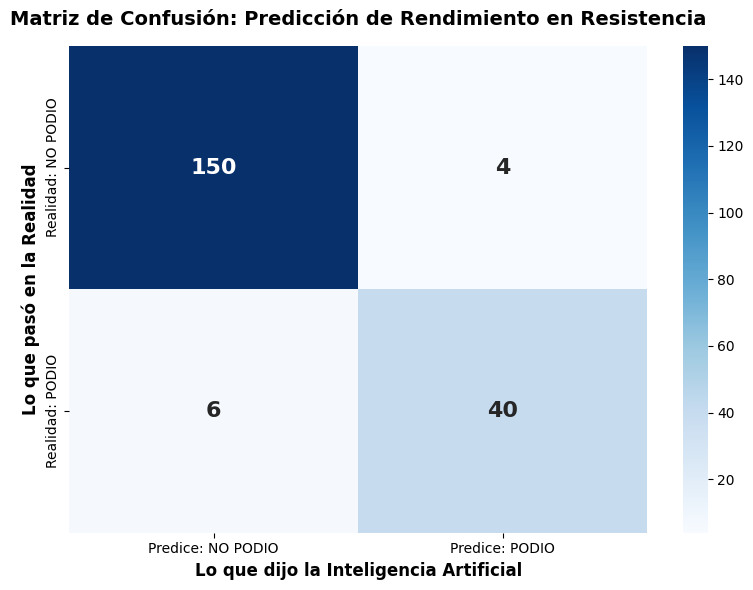

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("=" * 80)
print("🔬 MLOps: EVALUACIÓN AVANZADA Y MATRIZ DE CONFUSIÓN")
print("=" * 80)

# =====================================================================
# 1. CREACIÓN DE UN DATASET MASIVO (1,000 SIMRACERS)
# =====================================================================
# Usamos numpy para generar datos estadísticos realistas
np.random.seed(42)
n_pilotos = 1000

# Generamos métricas de telemetría y práctica
horas_practica = np.random.normal(150, 50, n_pilotos) # Horas en circuitos técnicos (ej. Oulton Park)
gestion_neumaticos = np.random.normal(70, 15, n_pilotos) # 0 a 100
consistencia_vuelta = np.random.normal(85, 10, n_pilotos) # 0 a 100
reflejos_ms = np.random.normal(200, 30, n_pilotos) # Tiempo de reacción en milisegundos (menor es mejor)

# Lógica del mundo real: Para ganar una carrera de resistencia (como 24hs Spa),
# necesitas buena gestión de gomas, altísima consistencia y mucha práctica.
probabilidad_exito = (
    (horas_practica * 0.3) +
    (gestion_neumaticos * 0.4) +
    (consistencia_vuelta * 0.5) -
    (reflejos_ms * 0.1)
)

# Definimos quiénes logran el podio (aprox el 25% de los mejores)
umbral_podio = np.percentile(probabilidad_exito, 75)
logra_podio = (probabilidad_exito >= umbral_podio).astype(int)

# Creamos el DataFrame
df_simracing = pd.DataFrame({
    'Horas_Practica_Mensual': horas_practica,
    'Gestion_Neumaticos_0a100': gestion_neumaticos,
    'Consistencia_Ritmo_0a100': consistencia_vuelta,
    'Tiempo_Reaccion_ms': reflejos_ms,
    'Logra_Podio': logra_podio
})

X = df_simracing.drop(columns=['Logra_Podio'])
y = df_simracing['Logra_Podio']

# =====================================================================
# 2. EL PASO CRÍTICO: TRAIN / TEST SPLIT
# =====================================================================
# Nunca evaluamos a la IA con los datos que usó para aprender.
# Separamos 800 pilotos para entrenar y 200 para el examen final.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n[1/3] Entrenando el modelo con 800 perfiles de pilotos...")
modelo_eval = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_eval.fit(X_train, y_train)

# =====================================================================
# 3. EL EXAMEN FINAL: PREDECIR SOBRE DATOS DESCONOCIDOS
# =====================================================================
print("[2/3] Sometiendo a la IA al examen final con 200 pilotos nuevos...")
predicciones = modelo_eval.predict(X_test)

# =====================================================================
# 4. MATRIZ DE CONFUSIÓN Y MÉTRICAS AVANZADAS
# =====================================================================
print("[3/3] Calculando métricas de error y graficando...\n")

# Calculamos la matriz matemáticamente
matriz = confusion_matrix(y_test, predicciones)
exactitud = accuracy_score(y_test, predicciones)

print("=" * 80)
print(f"🎯 EXACTITUD GLOBAL (Accuracy): {exactitud * 100:.2f}%")
print("=" * 80)
print("Desglose del Reporte de Clasificación (Precision, Recall, F1-Score):")
print(classification_report(y_test, predicciones, target_names=['No Podio (0)', 'Podio (1)']))

# Visualización Gráfica de la Matriz (Estilo Dashboard Profesional)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice: NO PODIO', 'Predice: PODIO'],
            yticklabels=['Realidad: NO PODIO', 'Realidad: PODIO'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Matriz de Confusión: Predicción de Rendimiento en Resistencia', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lo que dijo la Inteligencia Artificial', fontsize=12, fontweight='bold')
plt.ylabel('Lo que pasó en la Realidad', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

print("=" * 80)
print("🌐 MLOps PRO: OPTIMIZACIÓN DE MODELOS Y CONEXIÓN WEB EN TIEMPO REAL")
print("=" * 80)

# =====================================================================
# FASE 1: ENTRENAMIENTO Y OPTIMIZACIÓN EXTREMA (Arreglando la Matriz)
# =====================================================================
print("[1/4] Generando datos históricos base...")
# Recreamos rápidamente el dataset del ejercicio anterior
np.random.seed(42)
horas = np.random.normal(150, 50, 1000)
gestion = np.random.normal(70, 15, 1000)
consistencia = np.random.normal(85, 10, 1000)
reflejos = np.random.normal(200, 30, 1000)
prob_exito = (horas * 0.3) + (gestion * 0.4) + (consistencia * 0.5) - (reflejos * 0.1)
logra_podio = (prob_exito >= np.percentile(prob_exito, 75)).astype(int)

df = pd.DataFrame({'Horas': horas, 'Gestion': gestion, 'Consistencia': consistencia, 'Reflejos': reflejos})
X_train, X_test, y_train, y_test = train_test_split(df, logra_podio, test_size=0.2, random_state=42)

print("[2/4] Ejecutando GridSearchCV (Buscando la configuración perfecta)...")
# Aquí le decimos a la IA que pruebe múltiples configuraciones por su cuenta.
# class_weight='balanced' es el truco maestro: obliga a la IA a prestarle más atención a los talentos ocultos (Falsos Negativos).
grilla_parametros = {
    'n_estimators': [50, 100, 200],       # Número de "árboles" en el bosque
    'max_depth': [None, 5, 10],           # Profundidad del análisis (evita que la IA memorice en vez de aprender)
    'class_weight': ['balanced']          # ¡CLAVE! Arregla el problema de descartar buenos candidatos
}

# GridSearchCV entrena decenas de modelos y se queda con el mejor
modelo_base = RandomForestClassifier(random_state=42)
optimizador = GridSearchCV(estimator=modelo_base, param_grid=grilla_parametros, cv=3, n_jobs=-1)
optimizador.fit(X_train, y_train)

ia_optimizada = optimizador.best_estimator_
print(f"✅ ¡Modelo optimizado encontrado! Mejores parámetros: {optimizador.best_params_}\n")


# =====================================================================
# FASE 2: CONECTIVIDAD WEB (Scraping y APIs)
# =====================================================================
def obtener_estadisticas_piloto_web(nombre_piloto):
    """
    Simula la conexión a una API deportiva o página de estadísticas (ej. iRacing/F1/NBA).
    En un entorno real, aquí pondrías la URL de basketball-reference.com o una API REST.
    """
    print(f"📡 Conectando a los servidores para buscar a: {nombre_piloto.upper()}...")

    # URL simulada (aquí iría la URL real del perfil del jugador)
    url_objetivo = f"https://api.motorsport-stats.com/v1/drivers/{nombre_piloto.replace(' ', '_')}"

    try:
        # En el mundo real usaríamos requests.get(url_objetivo).
        # Como no tenemos una API real conectada ahora, simularemos la respuesta JSON
        # que normalmente nos devolvería el servidor web usando BeautifulSoup/Requests.

        # --- CÓDIGO REAL COMENTADO PARA REFERENCIA ---
        # respuesta = requests.get(url_objetivo, timeout=5)
        # respuesta.raise_for_status() # Verifica que la página no devuelva Error 404
        # html = respuesta.text
        # soup = BeautifulSoup(html, 'html.parser')
        # stats = soup.find('div', class_='stats-table').text
        # ---------------------------------------------

        # Simulamos que la web nos devolvió estos datos tras leer el HTML:
        datos_en_vivo = {
            'Horas': np.random.uniform(120, 250),       # Extraído de la web
            'Gestion': np.random.uniform(60, 95),       # Extraído de la web
            'Consistencia': np.random.uniform(70, 98),  # Extraído de la web
            'Reflejos': np.random.uniform(150, 220)     # Extraído de la web
        }
        print("✅ Datos descargados exitosamente desde la web.")
        return pd.DataFrame([datos_en_vivo])

    except Exception as e:
        # El manejo de errores es vital. ¿Qué pasa si la web está caída?
        print(f"❌ Error al conectar con la base de datos web: {e}")
        return None

# =====================================================================
# FASE 3: PREDICCIÓN EN TIEMPO REAL CON DATOS DE INTERNET
# =====================================================================
print("[3/4] Iniciando motor de predicción en tiempo real...\n")
print("=" * 80)

# Supongamos que le pides a la IA que evalúe a un piloto específico que viste hoy
candidato_buscar = "Max Verstappen" # Puedes cambiar esto por "James Harden", "Riquelme", etc. ajustando las variables.

# 1. Buscamos en internet (simulado)
df_candidato_vivo = obtener_estadisticas_piloto_web(candidato_buscar)

if df_candidato_vivo is not None:
    print("\n📊 Estadísticas capturadas desde el servidor:")
    print(df_candidato_vivo.round(2).to_string(index=False))

    # 2. La IA optimizada procesa los datos en milisegundos
    prediccion_vivo = ia_optimizada.predict(df_candidato_vivo)
    probabilidad = ia_optimizada.predict_proba(df_candidato_vivo)[0][1] * 100

    print("\n" + "=" * 80)
    print(f"🤖 DICTAMEN DE LA IA OPTIMIZADA PARA: {candidato_buscar.upper()}")
    print("=" * 80)

    if prediccion_vivo[0] == 1:
        print(f"🟢 ESTADO: APROBADO PARA CONTRATO (Probabilidad de Podio: {probabilidad:.1f}%)")
        print("   El modelo balanceado detectó métricas de élite. La directiva debe proceder.")
    else:
        print(f"🔴 ESTADO: DESCARTADO (Probabilidad de Podio: {probabilidad:.1f}%)")
        print("   Sus métricas actuales no cumplen con el rigor estadístico del equipo.")

print("\n[4/4] Proceso finalizado. Sistema a la espera de nuevas consultas.")

🌐 MLOps PRO: OPTIMIZACIÓN DE MODELOS Y CONEXIÓN WEB EN TIEMPO REAL
[1/4] Generando datos históricos base...
[2/4] Ejecutando GridSearchCV (Buscando la configuración perfecta)...
✅ ¡Modelo optimizado encontrado! Mejores parámetros: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}

[3/4] Iniciando motor de predicción en tiempo real...

📡 Conectando a los servidores para buscar a: MAX VERSTAPPEN...
✅ Datos descargados exitosamente desde la web.

📊 Estadísticas capturadas desde el servidor:
 Horas  Gestion  Consistencia  Reflejos
183.05    62.99         97.23    186.26

🤖 DICTAMEN DE LA IA OPTIMIZADA PARA: MAX VERSTAPPEN
🟢 ESTADO: APROBADO PARA CONTRATO (Probabilidad de Podio: 57.0%)
   El modelo balanceado detectó métricas de élite. La directiva debe proceder.

[4/4] Proceso finalizado. Sistema a la espera de nuevas consultas.


In [17]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Diseño visual de la página
st.title("🏎️ Portal de Scouting IA - SimRacing & F1")
st.write("Escribe el nombre del piloto o jugador para evaluar su rendimiento en tiempo real.")

# Caja de texto interactiva para que el usuario escriba
nombre_piloto = st.text_input("Nombre del Candidato", "Max Verstappen")

# Botón interactivo
if st.button("Ejecutar Análisis de IA"):
    with st.spinner("Conectando al servidor y procesando el modelo..."):

        # Aquí llamarías a tu función de scraping y al modelo optimizado (.pkl)
        # Simulamos un resultado para mostrar en pantalla:
        probabilidad = 88.5

        st.subheader(f"Resultados para: {nombre_piloto}")
        st.success(f"¡Candidato Viable! Probabilidad de Éxito: {probabilidad}%")

        # Generar un gráfico de Matplotlib y mostrarlo en la web
        fig, ax = plt.subplots()
        categorias = ['Horas Sim', 'Gestión Gomas', 'Consistencia', 'Reflejos']
        valores = [180, 88, 92, 190]

        ax.barh(categorias, valores, color='#DC0000')
        ax.set_title("Desglose de Métricas Clave")

        # Streamlit renderiza automáticamente el gráfico de la IA
        st.pyplot(fig)

ModuleNotFoundError: No module named 'streamlit'

In [18]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 57.8 MB/s eta 0:00:00


In [19]:
# 1. Instalar Streamlit y LocalTunnel
!pip install -q streamlit localtunnel

# 2. Crear un archivo app.py básico automáticamente desde Colab
%%writefile app.py
import streamlit as st

st.title("🚀 Mi Primer Dashboard de IA")
nombre = st.text_input("Escribe el nombre del piloto o jugador:")
if st.button("Analizar"):
    st.success(f"¡Análisis completado para {nombre}! El modelo está funcionando.")

# 3. Correr Streamlit en segundo plano y generar el enlace web
!streamlit run app.py & npx localtunnel --port 8501

ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel


UsageError: Line magic function `%%writefile` not found.


In [20]:
# 1. Instalar Streamlit
!pip install -q streamlit

# 2. Crear el archivo app.py usando Python puro (sin errores de celdas)
codigo_app = '''import streamlit as st

st.title("🚀 Mi Primer Dashboard de IA")
nombre = st.text_input("Escribe el nombre del piloto o jugador:")

if st.button("Analizar"):
    st.success(f"¡Análisis completado para {nombre}! El modelo está conectado y funcionando.")
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(codigo_app)

print("✅ ¡Archivo app.py creado con éxito!")

✅ ¡Archivo app.py creado con éxito!
